In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)]

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
!ls /kaggle/input/datasets/kevinjosum/flowers-split/flowers_split
# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

test  train


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import os
import tensorflow as tf
from tensorflow.keras import models
from tensorflow.keras import layers
from tensorflow.keras.applications import VGG16
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import optimizers

2026-04-22 00:23:19.872308: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776817400.098271      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776817400.170337      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776817400.709123      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776817400.709169      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776817400.709172      23 computation_placer.cc:177] computation placer alr

In [3]:
train_dir = '/kaggle/input/datasets/kevinjosum/flowers-split/flowers_split/train'
test_dir = '/kaggle/input/datasets/kevinjosum/flowers-split/flowers_split//test'

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.2,
    zoom_range=0.3,
    horizontal_flip=True
)

Found 10577 images belonging to 13 classes.
(100, 120, 120, 3)


<Figure size 640x480 with 0 Axes>

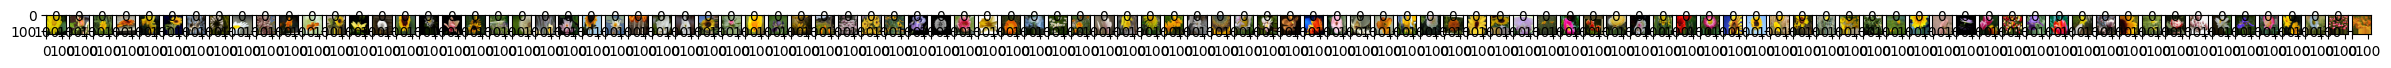

In [4]:
train_generator = train_datagen.flow_from_directory(
							train_dir,
							target_size = (120, 120),
							batch_size = 100,
							class_mode ='categorical',
							)


images , labels = train_generator[0]

print(images.shape)

plt.figure()
#subplot(r,c) provide the no. of rows and columns
f, axarr = plt.subplots(1, images.shape[0], figsize=(30, 4))

for i in range(images.shape[0]) :
  axarr[i].imshow(images[i])

In [5]:
import tensorflow as tf
from tensorflow.keras import layers, models

modely = models.Sequential()

# Entrada
modely.add(layers.Input(shape=(120,120,3)))

# Bloque 1
modely.add(layers.Conv2D(64, (3,3), padding='same'))
modely.add(layers.BatchNormalization())
modely.add(layers.Activation('relu'))

modely.add(layers.Conv2D(64, (3,3), padding='same'))
modely.add(layers.BatchNormalization())
modely.add(layers.Activation('relu'))

modely.add(layers.MaxPooling2D((2,2)))

# Bloque 2
modely.add(layers.Conv2D(128, (3,3), padding='same'))
modely.add(layers.BatchNormalization())
modely.add(layers.Activation('relu'))

modely.add(layers.Conv2D(128, (3,3), padding='same'))
modely.add(layers.BatchNormalization())
modely.add(layers.Activation('relu'))

modely.add(layers.MaxPooling2D((2,2)))

# Bloque 3
modely.add(layers.Conv2D(256, (3,3), padding='same'))
modely.add(layers.BatchNormalization())
modely.add(layers.Activation('relu'))

modely.add(layers.Conv2D(256, (3,3), padding='same'))
modely.add(layers.BatchNormalization())
modely.add(layers.Activation('relu'))

modely.add(layers.MaxPooling2D((2,2)))

# Bloque 4 
modely.add(layers.Conv2D(512, (3,3), padding='same'))
modely.add(layers.BatchNormalization())
modely.add(layers.Activation('relu'))

modely.add(layers.Conv2D(512, (3,3), padding='same'))
modely.add(layers.BatchNormalization())
modely.add(layers.Activation('relu'))

modely.add(layers.MaxPooling2D((2,2)))

# Pool global
modely.add(layers.GlobalAveragePooling2D())

# Clasificador
modely.add(layers.Dense(256, activation='relu'))
modely.add(layers.Dropout(0.5))


modely.add(layers.Dense(13, activation='softmax'))

modely.compile(
    loss='categorical_crossentropy',
    optimizer=optimizers.Adam(learning_rate=1e-4),
    metrics=['accuracy']
)

modely.summary()

I0000 00:00:1776817439.675745      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1776817439.681790      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 120, 120, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 120, 120, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 120, 120, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 120, 120, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 120, 120, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 120, 120, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 60, 60, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 60, 60, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 60, 60, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 60, 60, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 60, 60, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 60, 60, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 30, 30, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 30, 30, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 30, 30, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 30, 30, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 30, 30, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 30, 30, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 15, 15, 512)    │     1,180,16

 Total params: 4,827,725 (18.42 MB)

 Trainable params: 4,823,885 (18.40 MB)

 Non-trainable params: 3,840 (15.00 KB)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/70


I0000 00:00:1776817448.265455      82 service.cc:152] XLA service 0x7de13820f450 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776817448.265494      82 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1776817448.265497      82 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1776817449.452789      82 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-04-22 00:24:29.063044: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-22 00:24:29.243740: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1776817483.923643      82 device_co

 12/106 ━━━━━━━━━━━━━━━━━━━━ 1:07 714ms/step - accuracy: 0.1713 - loss: 2.8178

2026-04-22 00:25:08.994054: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-22 00:25:09.166088: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


106/106 ━━━━━━━━━━━━━━━━━━━━ 146s 999ms/step - accuracy: 0.3491 - loss: 2.0283
Epoch 2/70
106/106 ━━━━━━━━━━━━━━━━━━━━ 57s 531ms/step - accuracy: 0.5632 - loss: 1.3037
Epoch 3/70
106/106 ━━━━━━━━━━━━━━━━━━━━ 55s 511ms/step - accuracy: 0.6379 - loss: 1.0940
Epoch 4/70
106/106 ━━━━━━━━━━━━━━━━━━━━ 55s 520ms/step - accuracy: 0.6918 - loss: 0.9720
Epoch 5/70
106/106 ━━━━━━━━━━━━━━━━━━━━ 56s 527ms/step - accuracy: 0.7086 - loss: 0.9056
Epoch 6/70
106/106 ━━━━━━━━━━━━━━━━━━━━ 54s 503ms/step - accuracy: 0.7326 - loss: 0.8180
Epoch 7/70
106/106 ━━━━━━━━━━━━━━━━━━━━ 53s 498ms/step - accuracy: 0.7624 - loss: 0.7357
Epoch 8/70
106/106 ━━━━━━━━━━━━━━━━━━━━ 54s 502ms/step - accuracy: 0.7640 - loss: 0.7270
Epoch 9/70
106/106 ━━━━━━━━━━━━━━━━━━━━ 54s 505ms/step - accuracy: 0.7977 - loss: 0.6421
Epoch 10/70
106/106 ━━━━━━━━━━━━━━━━━━━━ 54s 509ms/step - accuracy: 0.8059 - loss: 0.6082
Epoch 11/70
106/106 ━━━━━━━━━━━━━━━━━━━━ 56s 523ms/step - accuracy: 0.8188 - loss: 0.5666
Epoch 12/70
106/106 ━━━━━━━━━

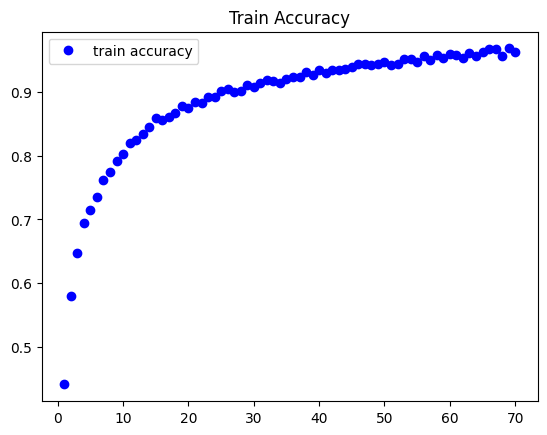

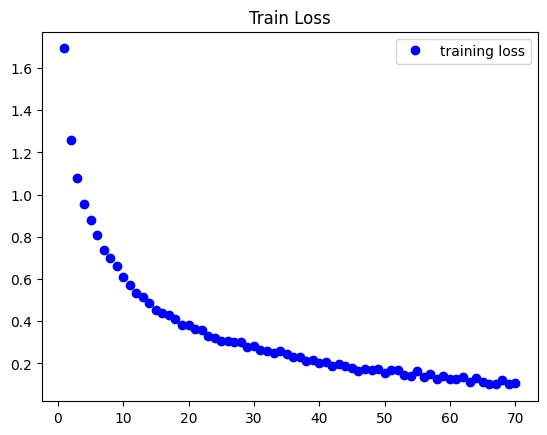

In [6]:
history = modely.fit(
    train_generator,
    epochs=70,
)

acc = history.history['accuracy']
loss = history.history['loss']

epochs = range(1, len(acc) + 1)

plt.plot(epochs, acc, 'bo', label='train accuracy')
plt.title('Train Accuracy')
plt.legend()

plt.figure()

plt.plot(epochs, loss, 'bo', label='training loss')
plt.title('Train Loss')
plt.legend()

plt.show()

In [7]:
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(120, 120),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

test_loss, test_acc = modely.evaluate(test_generator)

print('\nTest accuracy:\n', test_acc)

Found 2646 images belonging to 13 classes.
83/83 ━━━━━━━━━━━━━━━━━━━━ 25s 226ms/step - accuracy: 0.6830 - loss: 1.6388

Test accuracy:
 0.6723356246948242


In [8]:
import numpy as np

y_pred = modely.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)

y_true = test_generator.classes

83/83 ━━━━━━━━━━━━━━━━━━━━ 6s 59ms/step


In [9]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred_classes))

              precision    recall  f1-score   support

           0       0.94      0.91      0.92       200
           1       0.69      0.73      0.71       196
           2       0.85      0.78      0.81       205
           3       0.93      0.68      0.79       196
           4       1.00      0.09      0.16       210
           5       1.00      0.10      0.18       194
           6       0.97      0.91      0.94       211
           7       1.00      0.55      0.71       211
           8       0.88      0.65      0.75       210
           9       0.92      0.49      0.64       200
          10       0.47      1.00      0.64       206
          11       0.99      0.85      0.92       210
          12       0.29      1.00      0.45       197

    accuracy                           0.67      2646
   macro avg       0.84      0.67      0.66      2646
weighted avg       0.84      0.67      0.66      2646



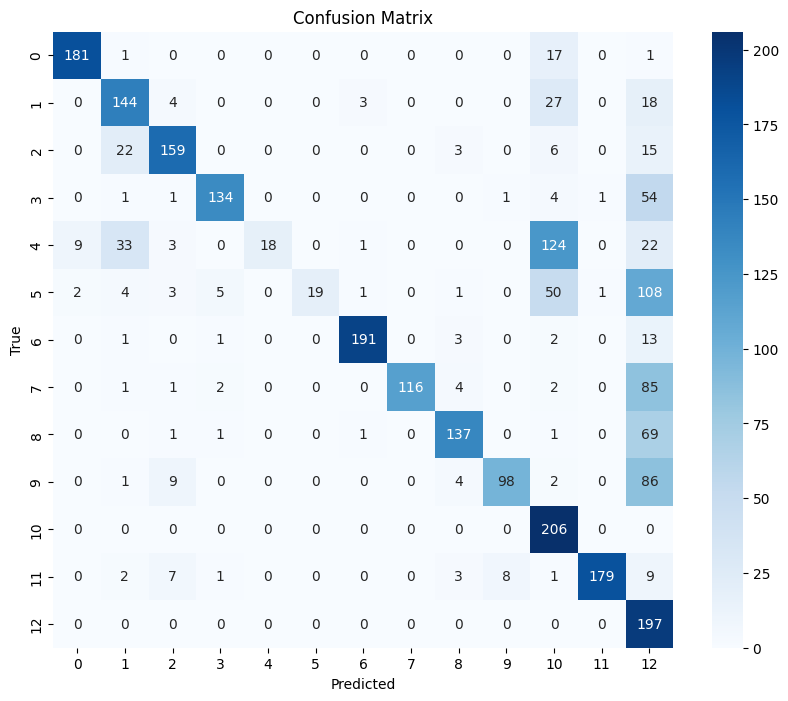

In [10]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [11]:
print(test_generator.class_indices)

{'black_eyed_susan': 0, 'calendula': 1, 'california_poppy': 2, 'common_daisy': 3, 'coreopsis': 4, 'daffodil': 5, 'dandelion': 6, 'iris': 7, 'magnolia': 8, 'rose': 9, 'sunflower': 10, 'tulip': 11, 'water_lily': 12}


In [12]:
modely.save("/kaggle/working/mi_modelo.keras")